# EDA for the Considered Binary Systems

The goal of this notebook is to explore the dataset used in this study. We aim to address the following key questions:

- How is the data distributed? Are there any imbalances?
- What are the ranges of the input features?
- Are the features correlated, and if so, to what extent?

By answering these questions, we can gain insights into how to design a suitable approach for applying physics-informed neural networks (PINNs). This analysis also helps us identify potential limitations and understand what our proposed approach can or cannot cover.

It's important to note that the selected features are based on the UNIFAC thermodynamic model, which describes the activity coefficient as a function of molar fraction, surface area (R), molecular volume (Q), and temperature. Therefore, these features were chosen for further evaluation.

## Dependencies

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import os

from pathlib import Path

## Exploratory Data Analysis

### Process the raw data

Executing the preprocessing script to transform the raw dataset:

In [2]:
sys.path.append(os.path.abspath(os.path.join("..", "src")))

from data.data_processing import DataProcessing as dp

data_processing_exec = dp()
data_processing_exec.process_raw_dataset()

print("Data successfully saved!")

Data successfully saved!


### Reading the data

Defining the data path conveniently:

In [3]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [4]:
raw_df = pd.read_csv(DATA_PATH / "processed" / "toy_problem_input_dataset.csv")

raw_df

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
4035,13.9726,11.536,0.96,3.9243,3.668,0.04,509.434,0.000370,0.496548
4036,13.9726,11.536,0.97,3.9243,3.668,0.03,532.267,0.000180,0.453976
4037,13.9726,11.536,0.98,3.9243,3.668,0.02,568.855,0.000060,0.389959
4038,13.9726,11.536,0.99,3.9243,3.668,0.01,600.617,0.000010,0.340720


Remove rows with NaN values:

In [5]:
df_all_data_points = raw_df.dropna().reset_index(drop=True)

df_all_data_points

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
4031,13.9726,11.536,0.96,3.9243,3.668,0.04,509.434,0.000370,0.496548
4032,13.9726,11.536,0.97,3.9243,3.668,0.03,532.267,0.000180,0.453976
4033,13.9726,11.536,0.98,3.9243,3.668,0.02,568.855,0.000060,0.389959
4034,13.9726,11.536,0.99,3.9243,3.668,0.01,600.617,0.000010,0.340720


### Check how data is distributed by features

#### Gamma 1

Histogram:

<Figure size 800x600 with 0 Axes>

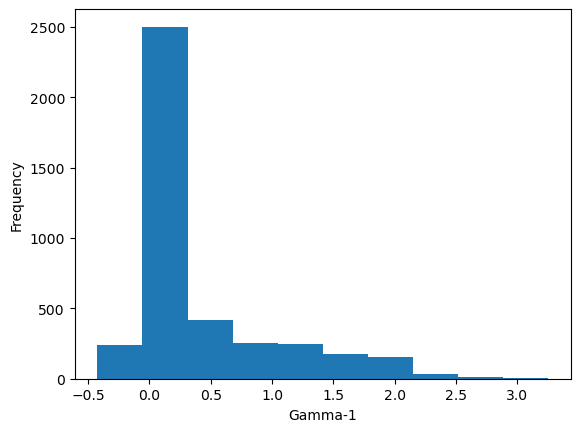

In [6]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="gamma_1", legend=False)
plt.xlabel("Gamma-1")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

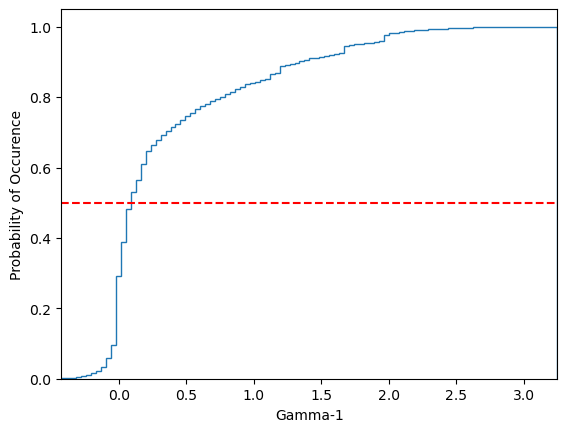

In [7]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="gamma_1", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points.gamma_1.min(),
    xmax=df_all_data_points.gamma_1.max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points.gamma_1.min(), df_all_data_points.gamma_1.max())

plt.xlabel("Gamma-1")
plt.ylabel("Probability of Occurence")

plt.show()


#### Gamma 2

Histogram:

<Figure size 800x600 with 0 Axes>

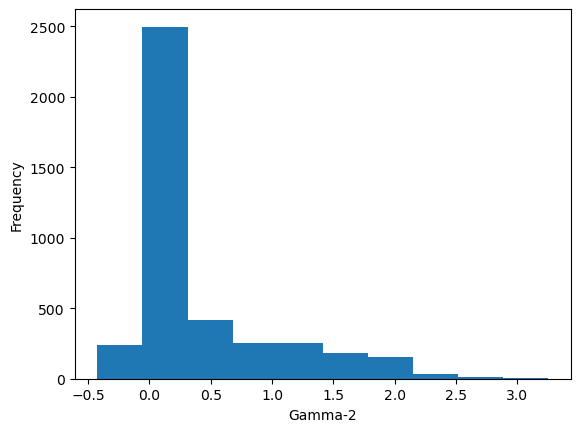

In [8]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="gamma_2", legend=False)
plt.xlabel("Gamma-2")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

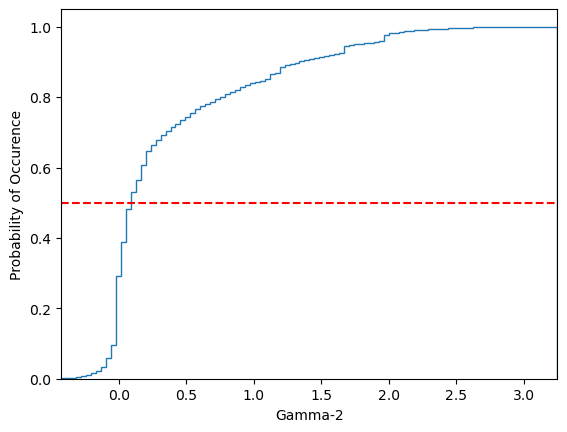

In [9]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="gamma_2", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points.gamma_2.min(),
    xmax=df_all_data_points.gamma_2.max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points.gamma_2.min(), df_all_data_points.gamma_2.max())

plt.xlabel("Gamma-2")
plt.ylabel("Probability of Occurence")

plt.show()

#### Surface Area 1 (r_1)

Histogram:

<Figure size 800x600 with 0 Axes>

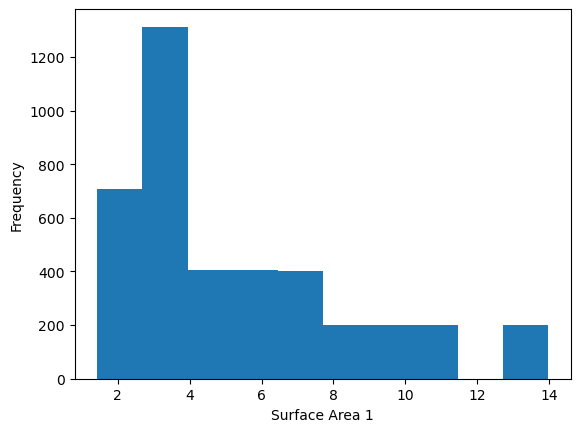

In [10]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="r_1", legend=False)
plt.xlabel("Surface Area 1")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

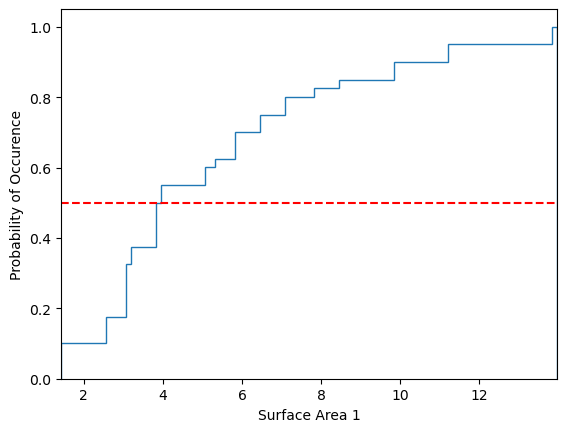

In [11]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="r_1", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points.r_1.min(),
    xmax=df_all_data_points.r_1.max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points.r_1.min(), df_all_data_points.r_1.max())

plt.xlabel("Surface Area 1")
plt.ylabel("Probability of Occurence")

plt.show()

#### Surface Area 2 (r_2)

Histogram:

<Figure size 800x600 with 0 Axes>

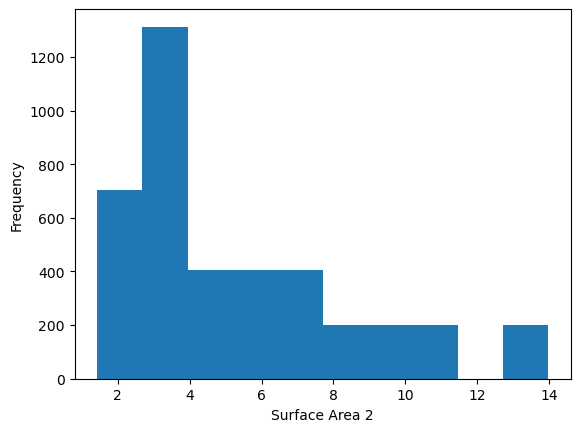

In [12]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="r_2", legend=False)
plt.xlabel("Surface Area 2")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

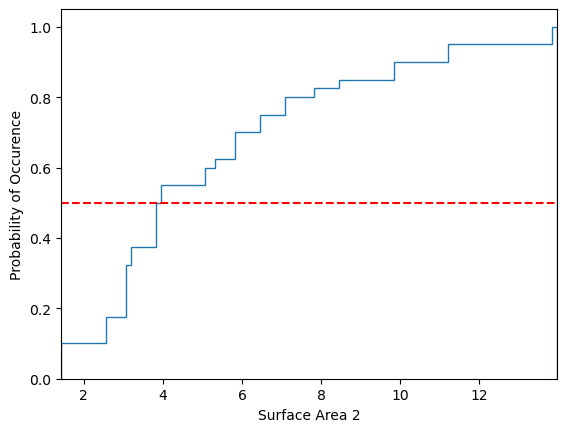

In [13]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="r_2", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points.r_2.min(),
    xmax=df_all_data_points.r_2.max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points.r_2.min(), df_all_data_points.r_2.max())

plt.xlabel("Surface Area 2")
plt.ylabel("Probability of Occurence")

plt.show()

#### Molecular Volume 1 (q_1)

Histogram:

<Figure size 800x600 with 0 Axes>

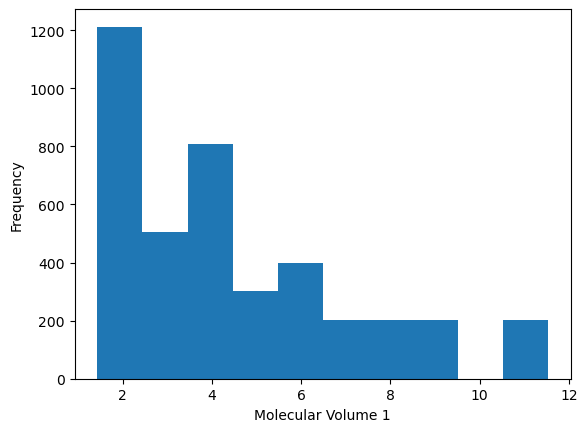

In [14]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="q_1", legend=False)
plt.xlabel("Molecular Volume 1")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

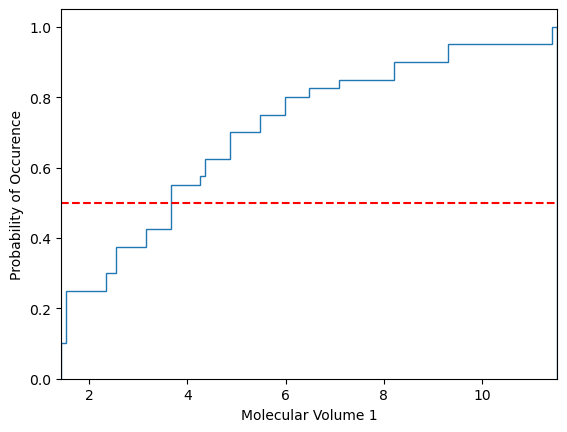

In [15]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="q_1", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points.q_1.min(),
    xmax=df_all_data_points.q_1.max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points.q_1.min(), df_all_data_points.q_1.max())

plt.xlabel("Molecular Volume 1")
plt.ylabel("Probability of Occurence")

plt.show()

#### Molecular Volume 2 (q_2)

Histogram:

<Figure size 800x600 with 0 Axes>

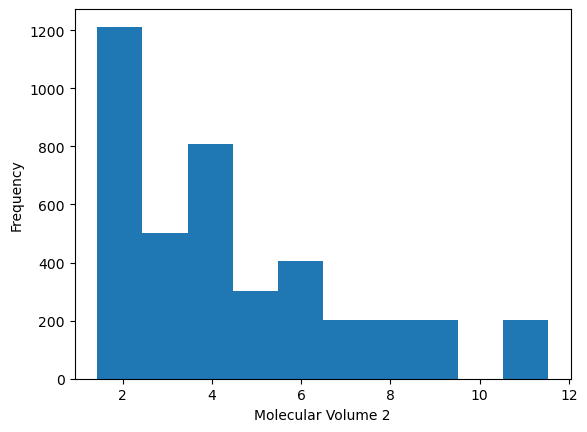

In [16]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="q_2", legend=False)
plt.xlabel("Molecular Volume 2")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

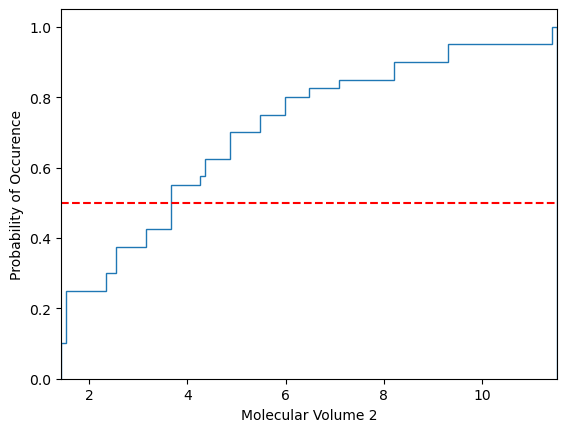

In [17]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="q_2", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points.q_2.min(),
    xmax=df_all_data_points.q_2.max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points.q_2.min(), df_all_data_points.q_2.max())

plt.xlabel("Molecular Volume 2")
plt.ylabel("Probability of Occurence")

plt.show()

#### Temperature

Histogram:

<Figure size 800x600 with 0 Axes>

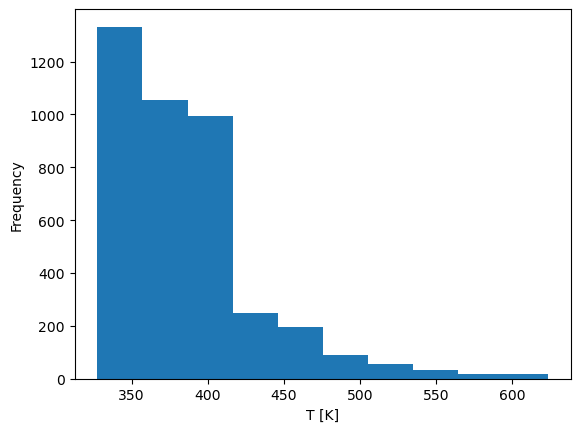

In [18]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(column="T", legend=False)
plt.xlabel("T [K]")

plt.show()

Cumulative distribution:

<Figure size 800x600 with 0 Axes>

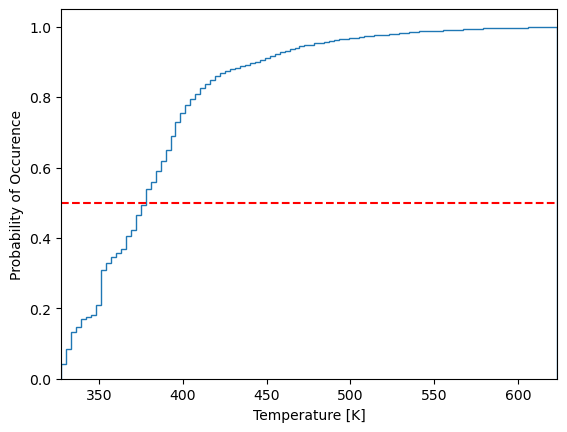

In [19]:
plt.figure(figsize=(8, 6))

df_all_data_points.plot.hist(
    column="T", bins=100, cumulative=True, density=True, histtype="step", legend=False
)

plt.hlines(
    y=0.5,
    xmin=df_all_data_points["T"].min(),
    xmax=df_all_data_points["T"].max(),
    colors="r",
    linestyles="--"
)

plt.xlim(df_all_data_points["T"].min(), df_all_data_points["T"].max())

plt.xlabel("Temperature [K]")
plt.ylabel("Probability of Occurence")

plt.show()

It is important to note that histograms and cumulative probability plots were not created for the molar fraction since its values are uniformly distributed between 0 and 1.

### Correlation Analysis

The goal of this analysis is two-fold:
- Check for linear correlations between different parameters/features (Pearson correlation);
- Check for monotonic (allowing non-linear) correlations between different parameters/features (Spearman correlation);

#### Linear Correlation

In [20]:
df_data_linear_corr = df_all_data_points.corr(method="pearson").round(2)

df_data_linear_corr

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
r_1,1.00,0.99,0.00,-0.09,-0.07,-0.00,0.49,-0.32,-0.16
q_1,0.99,1.00,0.00,-0.07,-0.06,-0.00,0.47,-0.28,-0.14
x_1,0.00,0.00,1.00,-0.00,-0.00,-1.00,-0.00,-0.46,0.47
r_2,-0.09,-0.07,-0.00,1.00,0.99,0.00,0.49,-0.16,-0.32
q_2,-0.07,-0.06,-0.00,0.99,1.00,0.00,0.47,-0.14,-0.28
x_2,-0.00,-0.00,-1.00,0.00,0.00,1.00,0.00,0.46,-0.47
T,0.49,0.47,-0.00,0.49,0.47,0.00,1.00,-0.38,-0.38
gamma_1,-0.32,-0.28,-0.46,-0.16,-0.14,0.46,-0.38,1.00,-0.26
gamma_2,-0.16,-0.14,0.47,-0.32,-0.28,-0.47,-0.38,-0.26,1.00


<Axes: >

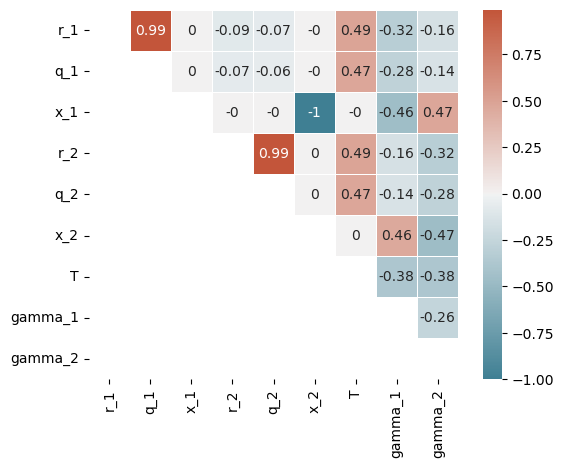

In [21]:
# Use a diverging palette to help the interpretation
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Mask to drop duplicated values due to corr symmetry
symmetry_mask = np.tril(np.ones_like(df_data_linear_corr, dtype=bool))

sns.heatmap(
    df_data_linear_corr, mask=symmetry_mask, cmap=cmap, square=True, linewidths=.5, annot=True
)

#### Monotonic Correlation

In [22]:
df_data_monotonic_corr = df_all_data_points.corr(method="spearman").round(2)

df_data_monotonic_corr

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
r_1,1.00,0.97,0.00,-0.14,-0.11,-0.00,0.49,-0.47,-0.25
q_1,0.97,1.00,0.00,-0.11,-0.09,-0.00,0.47,-0.41,-0.22
x_1,0.00,0.00,1.00,-0.00,-0.00,-1.00,-0.00,-0.49,0.49
r_2,-0.14,-0.11,-0.00,1.00,0.97,0.00,0.49,-0.25,-0.47
q_2,-0.11,-0.09,-0.00,0.97,1.00,0.00,0.47,-0.22,-0.41
x_2,-0.00,-0.00,-1.00,0.00,0.00,1.00,0.00,0.49,-0.49
T,0.49,0.47,-0.00,0.49,0.47,0.00,1.00,-0.51,-0.51
gamma_1,-0.47,-0.41,-0.49,-0.25,-0.22,0.49,-0.51,1.00,0.14
gamma_2,-0.25,-0.22,0.49,-0.47,-0.41,-0.49,-0.51,0.14,1.00


<Axes: >

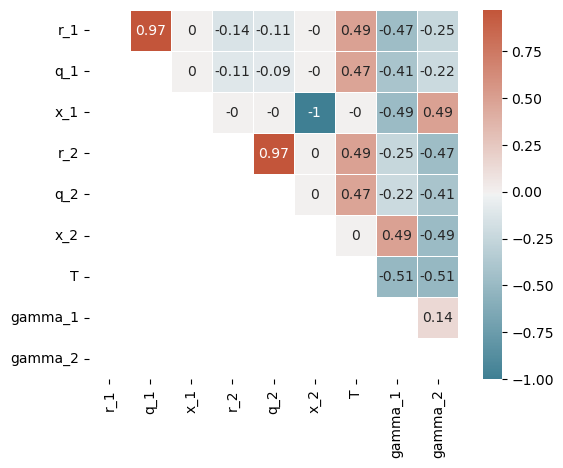

In [23]:
# Mask to drop duplicated values due to corr symmetry
symmetry_mask = np.tril(np.ones_like(df_data_monotonic_corr, dtype=bool))

sns.heatmap(
    df_data_monotonic_corr, mask=symmetry_mask, cmap=cmap, square=True, linewidths=.5, annot=True
)